In [1]:
%reload_ext autoreload
%autoreload 2

from src.backtest import Backtest, Filter, Univ
from src.pattern import Pattern, Bollinger, High, GoldenCross, Trending, Disparity, MFI

# 기본설정

In [2]:
start = "2000-01-01"
end = "2025-12-31"
univ = Univ(market=["KOSPI", 'KOSDAQ'])
bm = Pattern(name='모든주식')
bt = Backtest(start, end, benchmark=bm, by='day', univ=univ, db=0)

모든주식 | trim: 100%|██████████| 6409/6409 [00:07<00:00, 817.89it/s] 


볼린저돌파 | trim: 100%|██████████| 6409/6409 [00:01<00:00, 3841.72it/s]
볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | trim: 100%|██████████| 6409/6409 [00:00<00:00, 49736.52it/s]


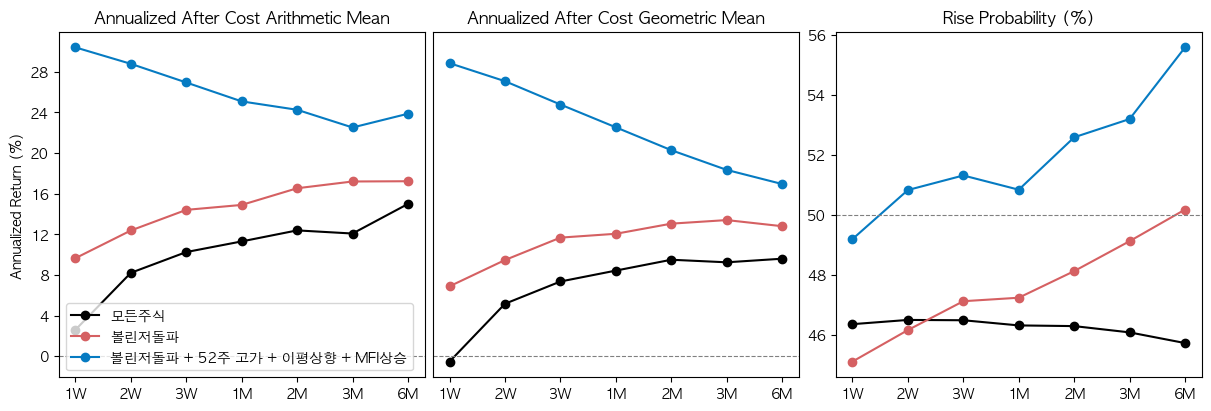

In [3]:
filter = Filter(market_cap=[])#, liquidity=[1,2,3,4,5], order=['market_cap', 'liquidity'])

uptrend = Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = MFI(name='MFI상승').on(trigger='above', threshold=50)

bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
high52w = High(name='52주 고가').on(window=240, threshold=0.90, stay_days=1)
bb_high52w = bb + high52w + uptrend + mfi_high
stats = bt.analyze(bb, bb_high52w, filter=filter)
stats.plot(annualized=True)

볼린저돌파 + 52주 고가 + 이평상향 + MFI상승: 100%|██████████| 6411/6411 [00:07<00:00, 854.97it/s]         


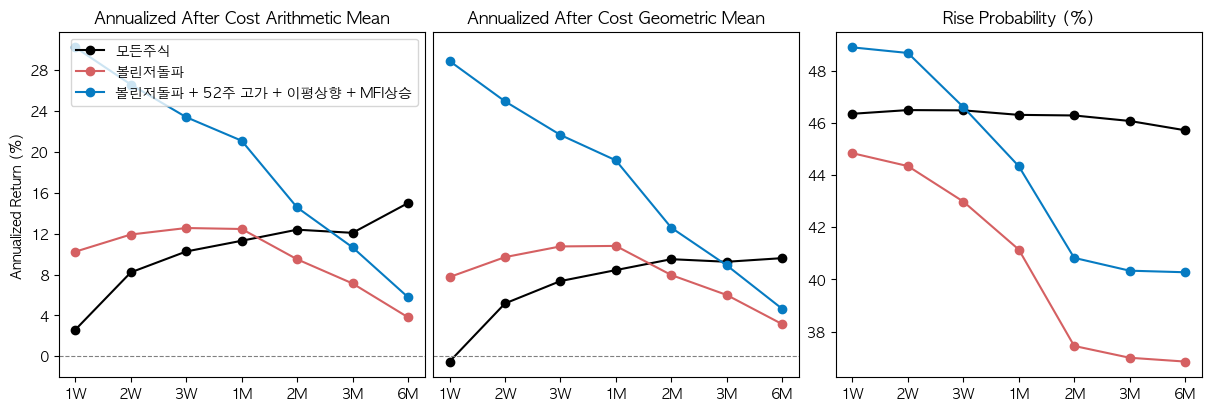

In [5]:
filter = Filter(market_cap=[])#, liquidity=[1,2,3,4,5], order=['market_cap', 'liquidity'])

uptrend = Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = MFI(name='MFI상승').on(trigger='above', threshold=50)

bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05, loss_cut='trailing_stop')
high52w = High(name='52주 고가').on(window=240, threshold=0.90, stay_days=1)
bb_high52w = bb + high52w + uptrend + mfi_high
stats = bt.analyze(bb, bb_high52w, filter=filter)
stats.plot(annualized=True)

볼린저돌파 + 52주 고가 + 이평상향 + MFI상승: 100%|██████████| 6411/6411 [00:07<00:00, 864.69it/s]         


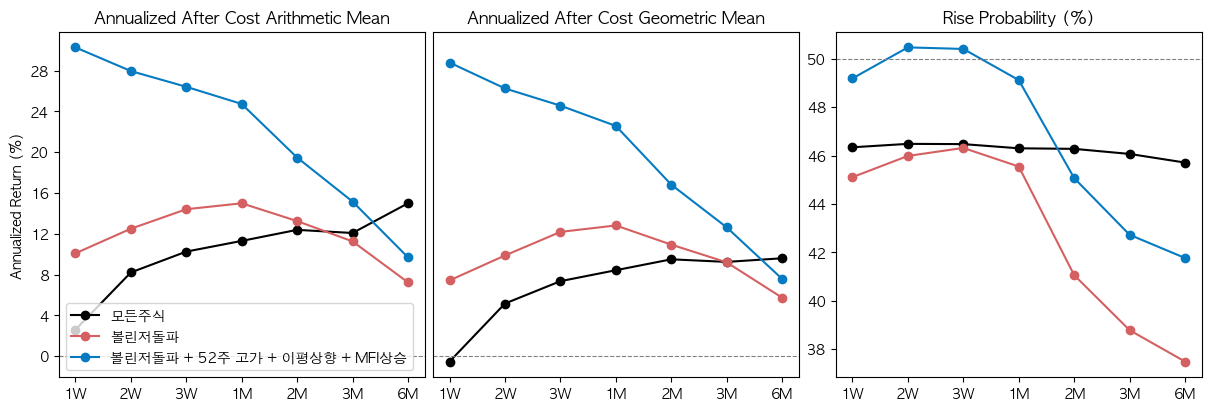

In [7]:
filter = Filter(market_cap=[])#, liquidity=[1,2,3,4,5], order=['market_cap', 'liquidity'])

uptrend = Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = MFI(name='MFI상승').on(trigger='above', threshold=50)

bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05, loss_cut='trailing_stop')
high52w = High(name='52주 고가').on(window=240, threshold=0.90, stay_days=1)
bb_high52w = bb + high52w + uptrend + mfi_high
stats = bt.analyze(bb, bb_high52w, filter=filter)
stats.plot(annualized=True)

볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | run: 100%|██████████| 6408/6408 [00:01<00:00, 5088.93it/s] 


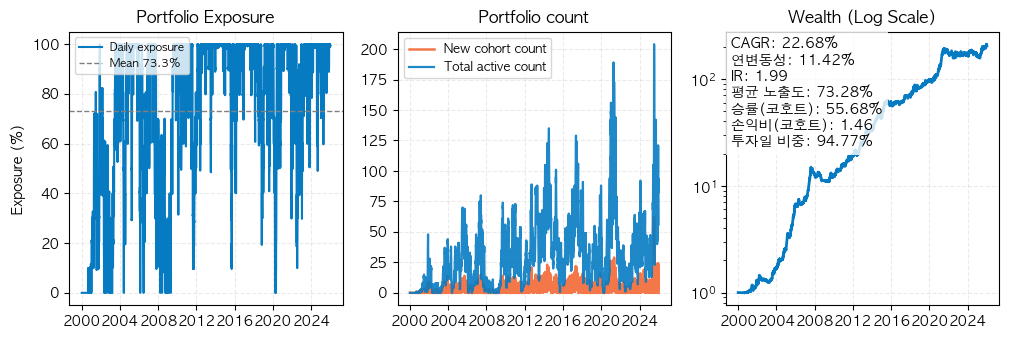

In [4]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가 + 이평상향 + MFI상승",
    target_horizon=10,
    trade_price_mode='당일종가'
)
simul.plot()

볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | run: 100%|██████████| 6408/6408 [00:01<00:00, 3846.74it/s]


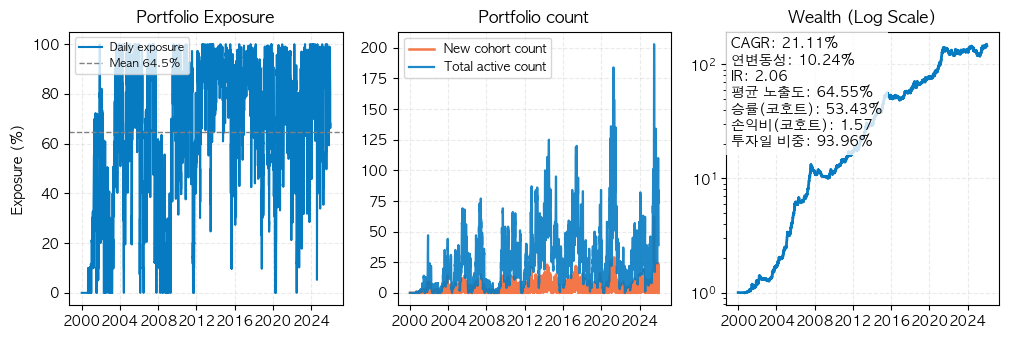

In [6]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가 + 이평상향 + MFI상승",
    target_horizon=10,
    trade_price_mode='당일종가'
)
simul.plot()

볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | run: 100%|██████████| 6408/6408 [00:01<00:00, 3769.68it/s]


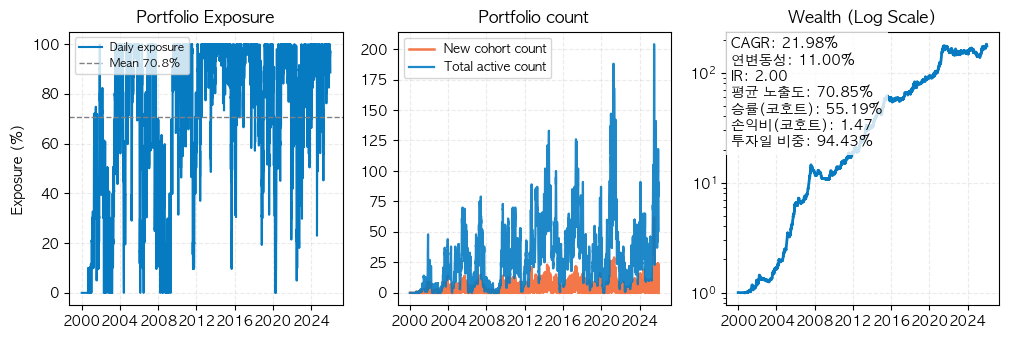

In [8]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가 + 이평상향 + MFI상승",
    target_horizon=10,
    trade_price_mode='당일종가'
)
simul.plot()

MFI과매도 | trim: 100%|██████████| 6409/6409 [00:00<00:00, 14211.56it/s]


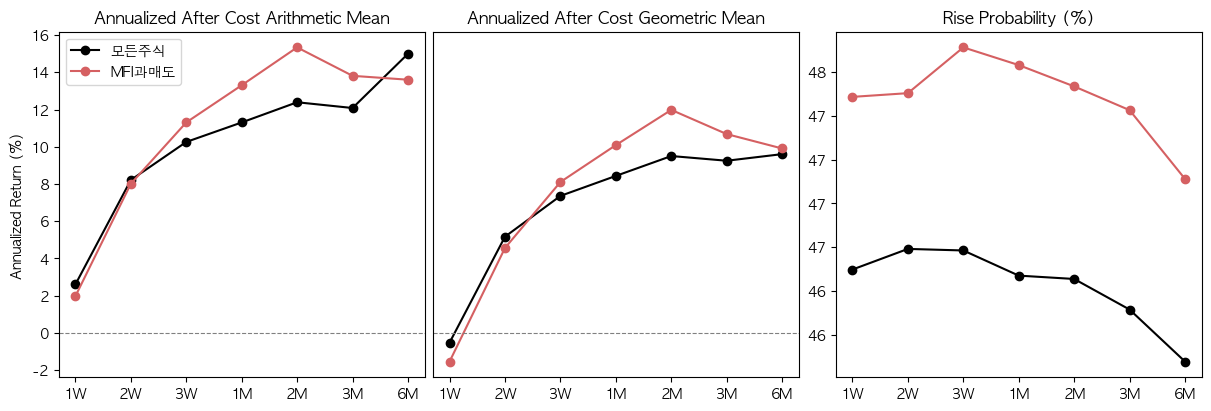

In [72]:
mfi = MFI(name='MFI과매도').on(
    trigger='below',
    threshold=30,
    cooldown_days=3,
)

stats = bt.analyze(mfi, filter=filter)
stats.plot(annualized=True)

MFI과매도 | run: 100%|██████████| 6408/6408 [00:07<00:00, 897.56it/s]


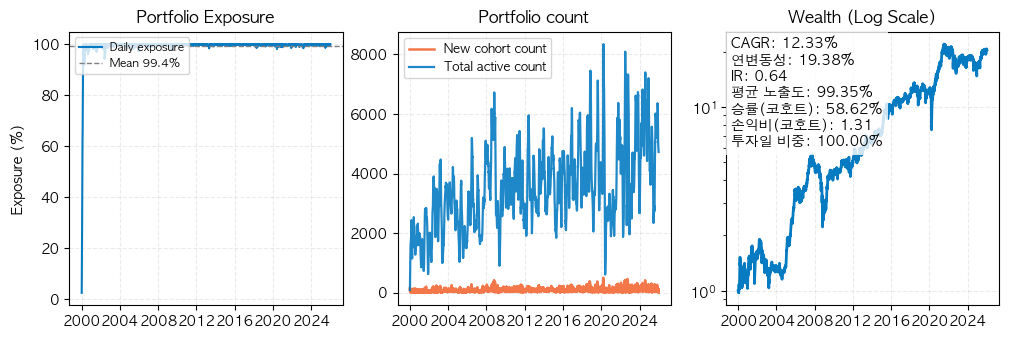

In [73]:
simul = bt.run(
    pattern='MFI과매도',
    target_horizon=40,
    trade_price_mode='당일종가',
)
simul.plot()